# Noisy 64-QAM constellation as a GPU density plot

Each received symbol is drawn as a single soft circular dot via
`Histogram.draw_points`. With `normalize=True` every dot integrates to 1, so the
accumulated histogram is a true 2-D density estimate of the received
constellation — the bright cores are the ideal symbol locations and the haze
around them is the AWGN cloud.

In [1]:
import sys
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

EXAMPLES = pathlib.Path.cwd()
BUILD = EXAMPLES.parent / "build" / "pyrendering"
sys.path.insert(0, str(BUILD))
sys.path.insert(0, str(EXAMPLES))
import pyrendering as pr

## Colormap helper

Map a `(H, W)` float32 density to RGBA via inferno on a log scale. `log_min` is
the absolute density value that maps to black; values below are clipped.

In [2]:
_inferno = mcm.get_cmap("inferno")


def apply_colormap(hist, cm=_inferno, max_intensity=None, log_min=0.1):
    peak = max_intensity if max_intensity is not None else hist.max()
    if peak > log_min:
        log_range = np.log(peak) - np.log(log_min)
        normalized = (np.log(np.clip(hist, log_min, peak)) - np.log(log_min)) / log_range
    else:
        normalized = np.zeros_like(hist)
    return (cm(normalized) * 255).astype(np.uint8)

/tmp/ipykernel_2032483/2142533163.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _inferno = mcm.get_cmap("inferno")


## Signal model

`qam_constellation` builds a unit-average-power square M-QAM grid (for 64-QAM:
the 8×8 grid `{-7,-5,…,5,7}` on each axis). `make_rx_symbols` draws random
symbols and adds complex AWGN: signal power is 1, so noise variance is `1/SNR`
and the per-dimension standard deviation is `sqrt(0.5/SNR)`.

In [3]:
def qam_constellation(m=64):
    k = int(round(np.sqrt(m)))
    if k * k != m:
        raise ValueError("m must be a perfect square (square QAM)")
    levels = np.arange(-(k - 1), k, 2, dtype=np.float64)  # e.g. [-7,-5,...,5,7]
    i, q = np.meshgrid(levels, levels)
    pts = (i + 1j * q).ravel()
    pts /= np.sqrt(np.mean(np.abs(pts) ** 2))  # normalise to unit average power
    return pts


def make_rx_symbols(constellation, n_symbols, snr_db=20.0, rng=None):
    """Random symbols + complex AWGN. Returns float32 (n_symbols, 2): [I, Q]."""
    if rng is None:
        rng = np.random.default_rng(0)
    tx = constellation[rng.integers(0, constellation.size, n_symbols)]
    snr = 10.0 ** (snr_db / 10.0)
    sigma = np.sqrt(0.5 / snr)  # per-dimension (I and Q each)
    noise = sigma * (rng.standard_normal(n_symbols) + 1j * rng.standard_normal(n_symbols))
    rx = tx + noise
    return np.stack([rx.real, rx.imag], axis=-1).astype(np.float32)

## Initialise the renderer

In [4]:
pr.init(validation_layers=False)
caps = pr.capabilities()
print("Hardware capabilities:")
for k, v in caps.items():
    print(f"  {k}: {v}")

Hardware capabilities:
  device_name: AMD Radeon 890M Graphics (RADV STRIX1)
  has_mesh_shaders: True
  mesh_max_group_count_x: 65535
  mesh_max_group_count_y: 65535
  mesh_max_group_count_z: 65535
  mesh_max_group_total: 4194304
  mesh_max_output_vertices: 256
  mesh_max_output_primitives: 256
  mesh_preferred_workgroup_size: 128


## Render

Accumulate symbols in batches, drawing each batch as soft dots. `draw_points` is
asynchronous (memcpy + submit); the GPU runs in the background and `download()`
blocks until everything is consumed.

In [32]:
pts.shape

(200000, 2)

In [84]:
width = height = 2048
total_symbols = 4_000_000
batch_size = 200_000
snr_db = 20.0
point_size = 2.5e-2   # dot radius in isometric units (~2.5 px at 2048²)
plot_range = 1.6

constellation = qam_constellation(16)
print(f"16-QAM, SNR = {snr_db:.0f} dB, {total_symbols:,} symbols, point_size = {point_size:g}")

hist = pr.Histogram(width, height)
hist.clear()

rng = np.random.default_rng(0)
n_batches = (total_symbols + batch_size - 1) // batch_size
rendered = 0
t_dsp_total = 0.0
t_draw_total = 0.0

for i in range(n_batches):
    n = min(batch_size, total_symbols - rendered)

    t0 = time.perf_counter()
    pts = make_rx_symbols(constellation, n, snr_db=snr_db, rng=rng)
    cpts = pts.view(dtype=np.complex64)
    cpts *= np.exp(1j * np.random.randn(cpts.size, 1) * np.abs(cpts)/7).astype(np.complex64)
    t_dsp_total += time.perf_counter() - t0

    t0 = time.perf_counter()
    hist.draw_points(
        pts,
        x_range=(-plot_range, plot_range),
        y_range=(-plot_range, plot_range),
        point_size=point_size,
        normalize=True,
    )
    t_draw_total += time.perf_counter() - t0

    rendered += n
    print(f"  [{i+1}/{n_batches}] {rendered:>10,} / {total_symbols:,} symbols", flush=True)

t0 = time.perf_counter()
data = hist.download()
t_download = time.perf_counter() - t0

print(f"Histogram: shape={data.shape}, min={data.min():.4f}, max={data.max():.4f}")
print(f"  DSP:        {t_dsp_total*1e3:7.1f} ms total")
print(f"  draw_points:{t_draw_total*1e3:7.1f} ms total  (memcpy + submit, GPU runs async)")
print(f"  download:   {t_download*1e3:7.1f} ms  (flush + readback)")

16-QAM, SNR = 20 dB, 4,000,000 symbols, point_size = 0.025
  [1/20]    200,000 / 4,000,000 symbols
  [2/20]    400,000 / 4,000,000 symbols
  [3/20]    600,000 / 4,000,000 symbols
  [4/20]    800,000 / 4,000,000 symbols
  [5/20]  1,000,000 / 4,000,000 symbols
  [6/20]  1,200,000 / 4,000,000 symbols
  [7/20]  1,400,000 / 4,000,000 symbols
  [8/20]  1,600,000 / 4,000,000 symbols
  [9/20]  1,800,000 / 4,000,000 symbols
  [10/20]  2,000,000 / 4,000,000 symbols
  [11/20]  2,200,000 / 4,000,000 symbols
  [12/20]  2,400,000 / 4,000,000 symbols
  [13/20]  2,600,000 / 4,000,000 symbols
  [14/20]  2,800,000 / 4,000,000 symbols
  [15/20]  3,000,000 / 4,000,000 symbols
  [16/20]  3,200,000 / 4,000,000 symbols
  [17/20]  3,400,000 / 4,000,000 symbols
  [18/20]  3,600,000 / 4,000,000 symbols
  [19/20]  3,800,000 / 4,000,000 symbols
  [20/20]  4,000,000 / 4,000,000 symbols
Histogram: shape=(2048, 2048), min=0.0000, max=17.4673
  DSP:          399.0 ms total
  draw_points:  209.2 ms total  (memcpy + su

## Display

Bright cores sit at the 64 ideal symbol locations; the Gaussian haze around each
is the 20 dB AWGN cloud. Tune `log_min` to reveal more (lower) or less (higher)
of the noise tails.

In [85]:
frame = apply_colormap(data, log_min=0.5)

In [86]:
from IPython.display import Image
import PIL

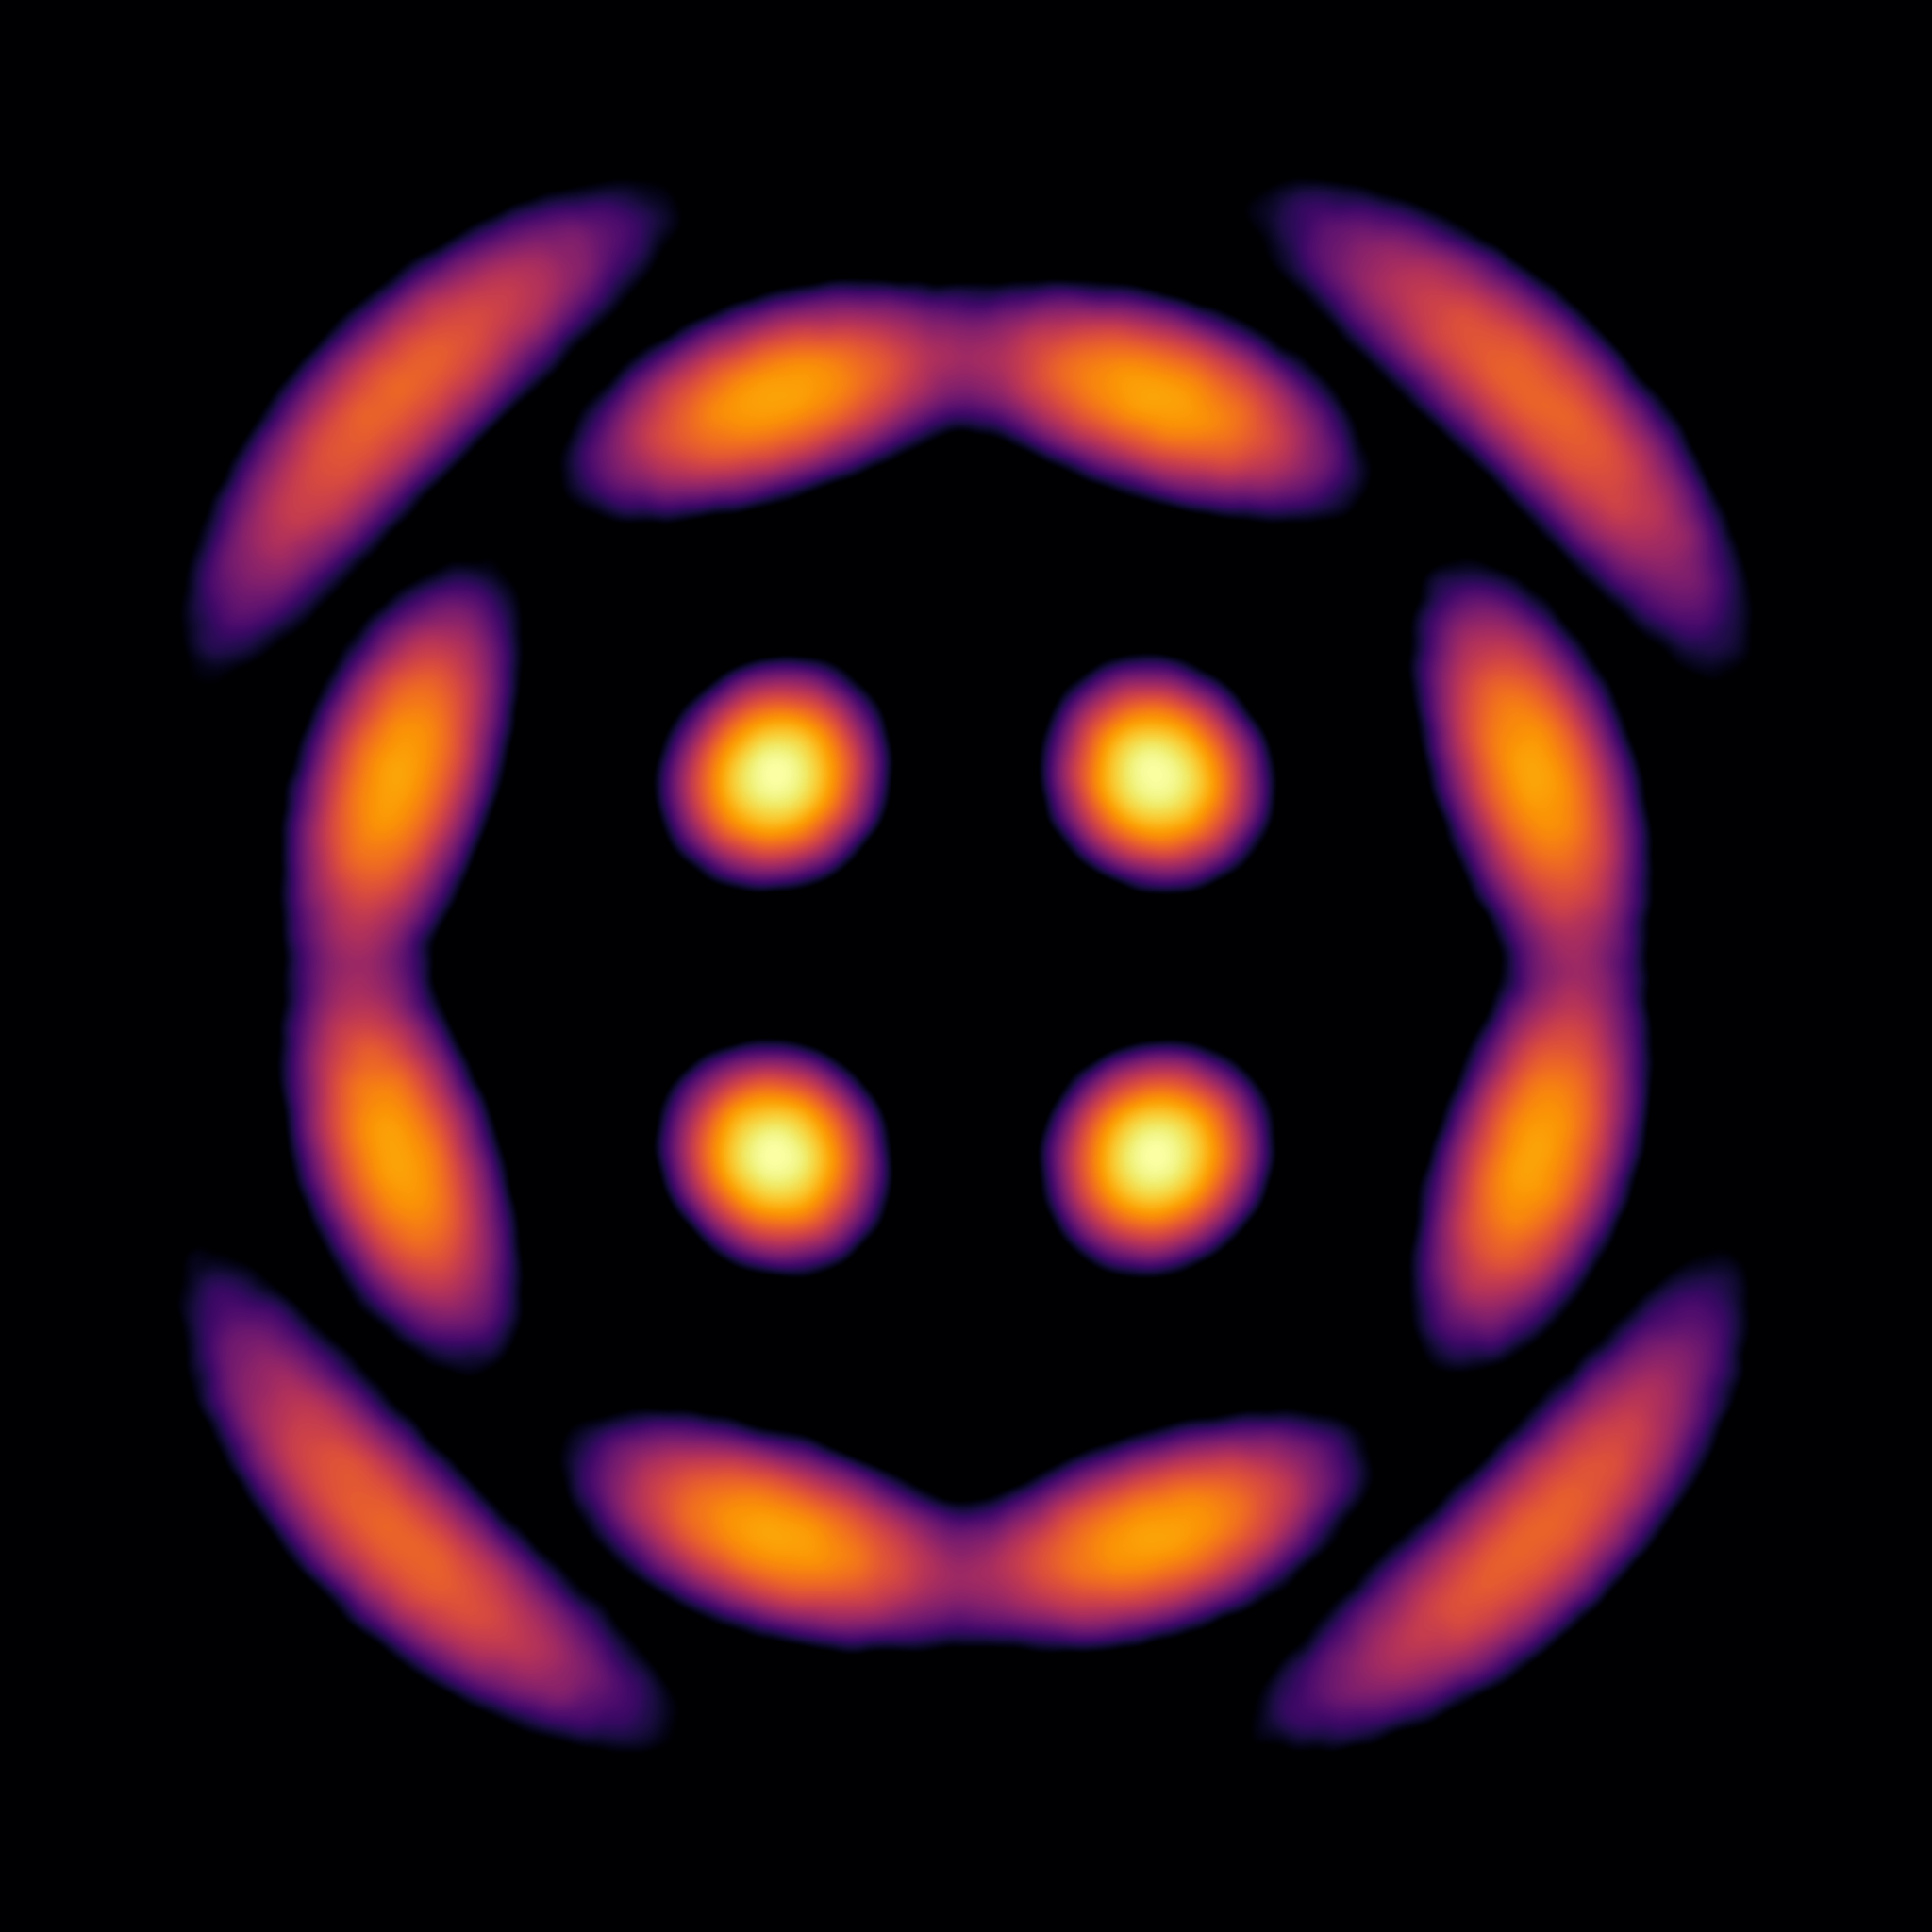

In [87]:
PIL.Image.fromarray(frame, "RGBA")

## Cleanup

In [63]:
del hist
pr.shutdown()